In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("/content/drive/MyDrive/PROJECT/loan.csv", low_memory=False)

df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 2.4+ GB


In [7]:
df.shape

(2260668, 145)

In [8]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=145)

In [9]:
columns = ['loan_amnt',
           'term',
           'int_rate',
           'annual_inc',
           'emp_length',
           'home_ownership',
           'purpose',
           'grade',
           'loan_status']

df = df[columns]

df.head()

,loan_amnt,term,int_rate,annual_inc,emp_length,home_ownership,purpose,grade,loan_status
0,2500,36 months,13.56,55000.0,10+ years,RENT,debt_consolidation,C,Current
1,30000,60 months,18.94,90000.0,10+ years,MORTGAGE,debt_consolidation,D,Current
2,5000,36 months,17.97,59280.0,6 years,MORTGAGE,debt_consolidation,D,Current
3,4000,36 months,18.94,92000.0,10+ years,MORTGAGE,debt_consolidation,D,Current
4,30000,60 months,16.14,57250.0,10+ years,MORTGAGE,debt_consolidation,C,Current


In [10]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
annual_inc,4
emp_length,146907
home_ownership,0
purpose,0
grade,0
loan_status,0


In [11]:
df['annual_inc'].fillna(df['annual_inc'].median(), inplace=True)

df['emp_length'].fillna(df['emp_length'].mode()[0], inplace=True)

In [12]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
annual_inc,0
emp_length,0
home_ownership,0
purpose,0
grade,0
loan_status,0


In [14]:
df['int_rate'] = df['int_rate'].astype(float)

In [15]:
df['term'] = df['term'].str.extract('(\d+)')

df['term'] = df['term'].astype(int)

In [16]:
df = df[df['loan_status'].isin(['Fully Paid','Charged Off'])]

df['loan_status'] = df['loan_status'].map({
    'Fully Paid':0,
    'Charged Off':1
})

In [17]:
df['credit_score'] = 850 - (df['int_rate']*5)

df['credit_score'] = df['credit_score'].astype(int)

df.head()

,loan_amnt,term,int_rate,annual_inc,emp_length,home_ownership,purpose,grade,loan_status,credit_score
100,30000,36,22.35,100000.0,5 years,MORTGAGE,debt_consolidation,D,0,738
152,40000,60,16.14,45000.0,< 1 year,MORTGAGE,credit_card,C,0,769
170,20000,36,7.56,100000.0,10+ years,MORTGAGE,credit_card,A,0,812
186,4500,36,11.31,38500.0,10+ years,RENT,credit_card,B,0,793
215,8425,36,27.27,450000.0,3 years,MORTGAGE,credit_card,E,0,713


In [18]:
encoder = LabelEncoder()

df['emp_length'] = encoder.fit_transform(df['emp_length'])

df['home_ownership'] = encoder.fit_transform(df['home_ownership'])

df['purpose'] = encoder.fit_transform(df['purpose'])

df['grade'] = encoder.fit_transform(df['grade'])

In [19]:
df.describe()

,loan_amnt,term,int_rate,annual_inc,emp_length,home_ownership,purpose,grade,loan_status,credit_score
count,1.303607e+06,1.303607e+06,1.303607e+06,1.303607e+06,1.303607e+06,1.303607e+06,1.303607e+06,1.303607e+06,1.303607e+06,1.303607e+06
mean,1.441681e+04,4.179659e+01,1.325722e+01,7.615899e+04,3.458957e+00,2.910724e+00,2.689780e+00,1.751486e+00,2.007162e-01,7.833267e+02
std,8.699542e+03,1.027218e+01,4.760544e+00,7.004890e+04,3.145339e+00,1.915902e+00,2.379108e+00,1.296941e+00,4.005363e-01,2.378972e+01
min,5.000000e+02,3.600000e+01,5.310000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.950000e+02
25%,8.000000e+03,3.600000e+01,9.750000e+00,4.584000e+04,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,7.700000e+02
50%,1.200000e+04,3.600000e+01,1.274000e+01,6.500000e+04,2.000000e+00,4.000000e+00,2.000000e+00,2.000000e+00,0.000000e+00,7.860000e+02
75%,2.000000e+04,3.600000e+01,1.599000e+01,9.000000e+04,6.000000e+00,5.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00,8.010000e+02
max,4.000000e+04,6.000000e+01,3.099000e+01,1.099920e+07,1.000000e+01,5.000000e+00,1.300000e+01,6.000000e+00,1.000000e+00,8.230000e+02


In [20]:
print(df['loan_amnt'].mean())

14416.805275669738


In [21]:
print(df['annual_inc'].mean())

76158.99211943477


In [22]:
print(df['int_rate'].mean())

13.257221202402249


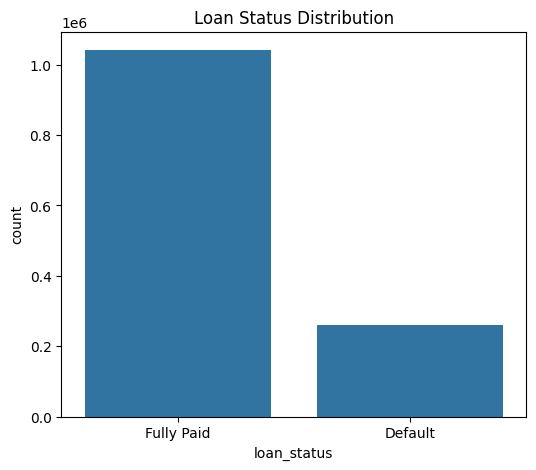

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(x='loan_status',data=df)

plt.xticks([0,1],['Fully Paid','Default'])

plt.title("Loan Status Distribution")

plt.show()

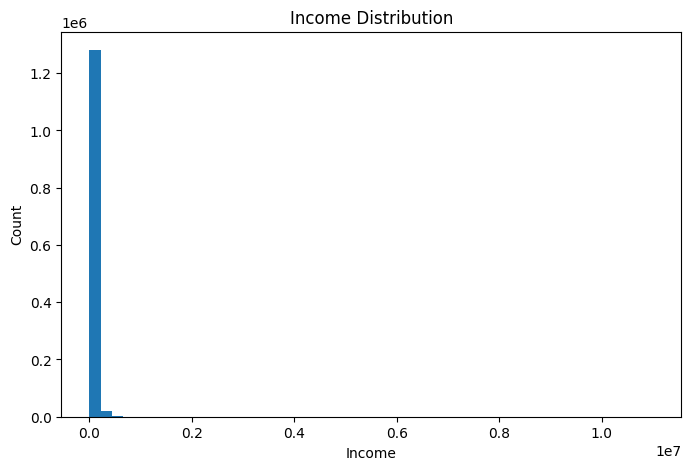

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df['annual_inc'],bins=50)

plt.title("Income Distribution")

plt.xlabel("Income")

plt.ylabel("Count")

plt.show()

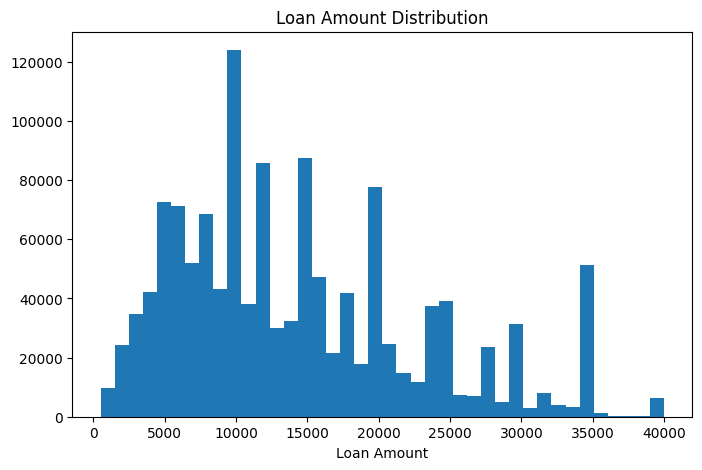

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df['loan_amnt'],bins=40)

plt.title("Loan Amount Distribution")

plt.xlabel("Loan Amount")

plt.show()

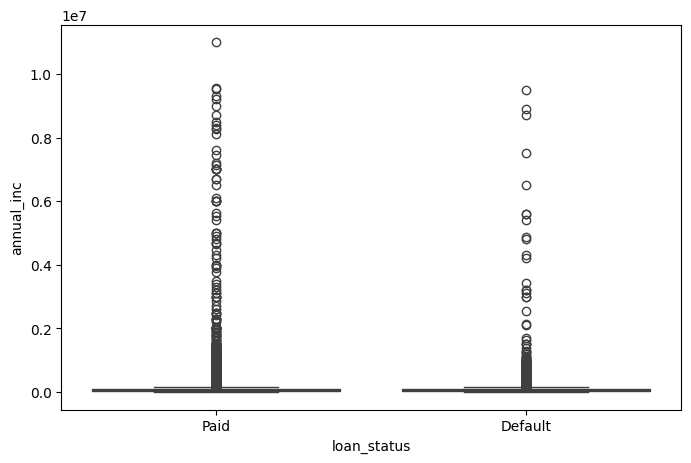

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x='loan_status',y='annual_inc',data=df)

plt.xticks([0,1],['Paid','Default'])

plt.show()

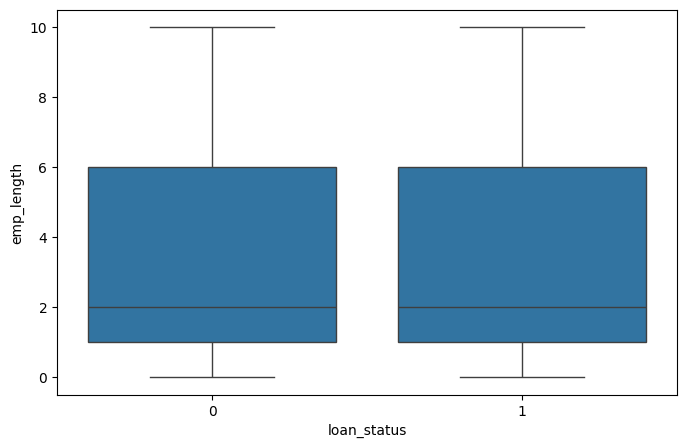

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x='loan_status',y='emp_length',data=df)

plt.show()

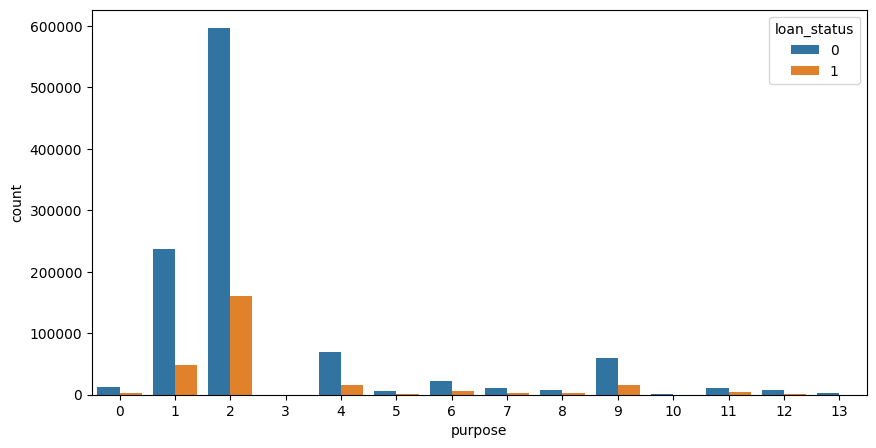

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(x='purpose',hue='loan_status',data=df)

plt.show()

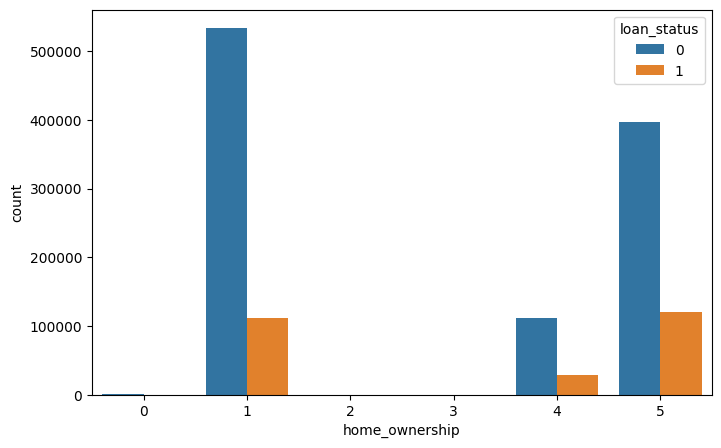

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(x='home_ownership',hue='loan_status',data=df)

plt.show()

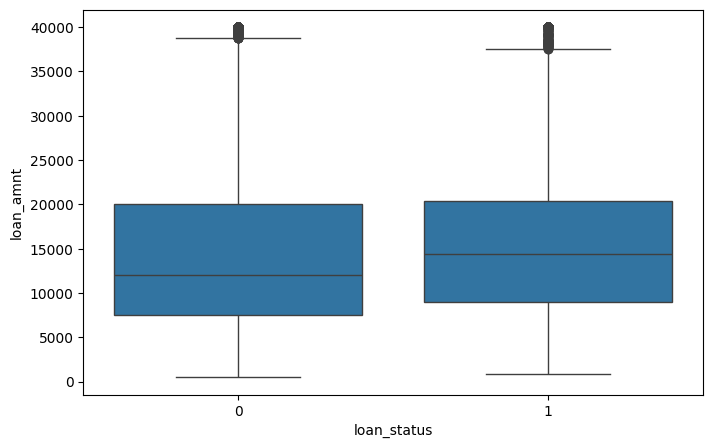

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x='loan_status',y='loan_amnt',data=df)

plt.show()

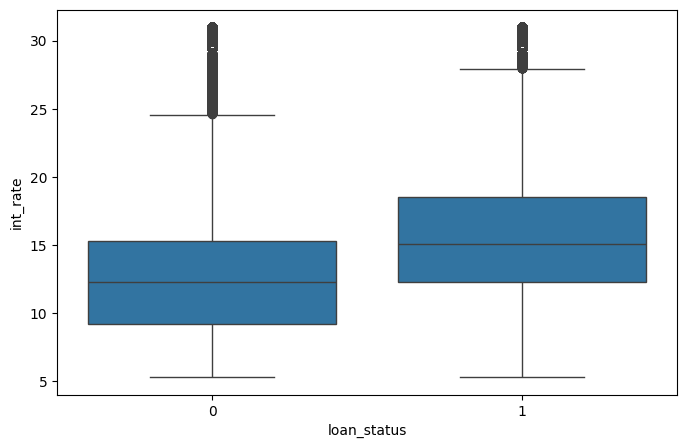

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x='loan_status',y='int_rate',data=df)

plt.show()

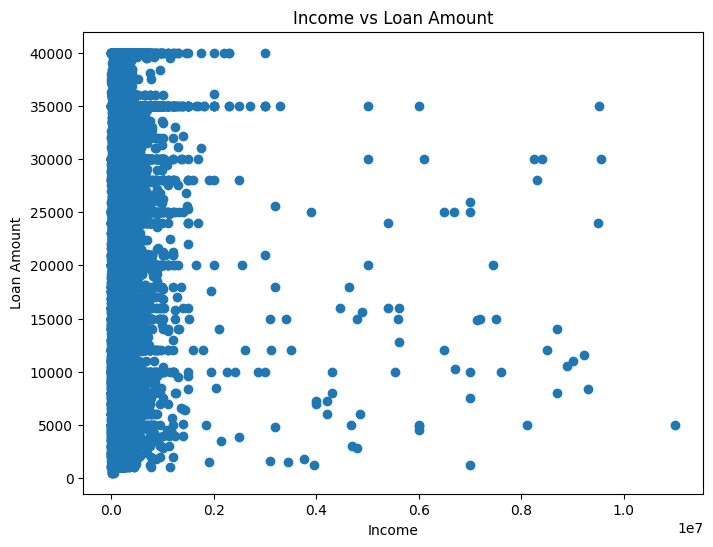

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(df['annual_inc'],df['loan_amnt'])

plt.xlabel("Income")

plt.ylabel("Loan Amount")

plt.title("Income vs Loan Amount")

plt.show()

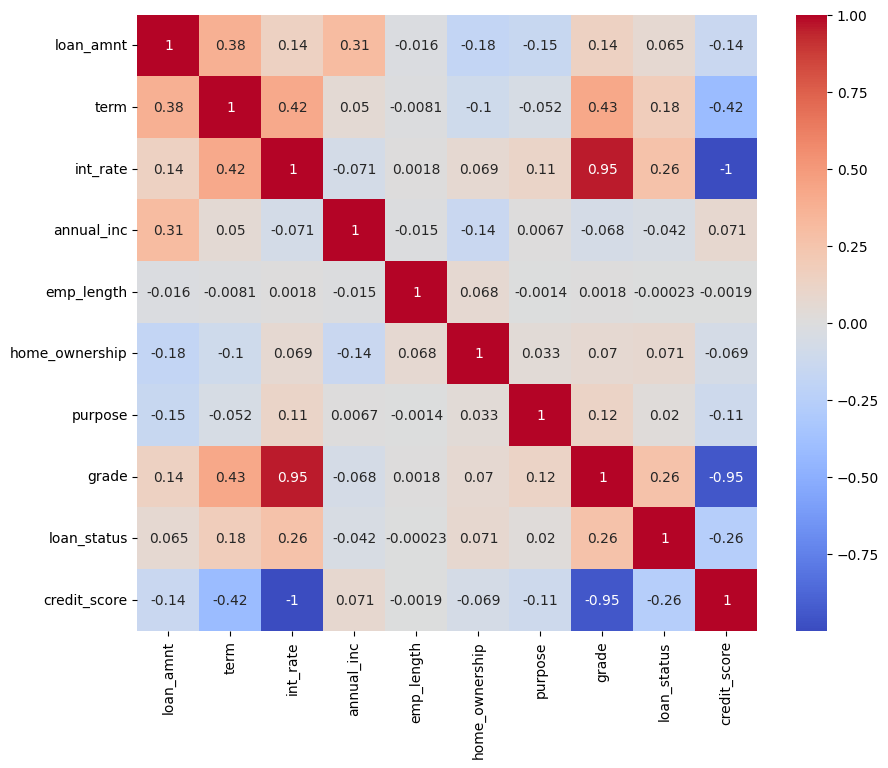

In [33]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.show()

In [34]:
def risk(score):

    if score>=750:
        return "Low Risk"

    elif score>=650:
        return "Medium Risk"

    else:
        return "High Risk"

df['Risk_Level']=df['credit_score'].apply(risk)

df[['credit_score','Risk_Level']].head()

,credit_score,Risk_Level
100,738,Medium Risk
152,769,Low Risk
170,812,Low Risk
186,793,Low Risk
215,713,Medium Risk


In [35]:
def risk(score):

    if score>=750:
        return "Low Risk"

    elif score>=650:
        return "Medium Risk"

    else:
        return "High Risk"

df['Risk_Level']=df['credit_score'].apply(risk)

df[['credit_score','Risk_Level']].head()

,credit_score,Risk_Level
100,738,Medium Risk
152,769,Low Risk
170,812,Low Risk
186,793,Low Risk
215,713,Medium Risk


In [37]:
df['Risk_Level'].value_counts()

,count
Risk_Level,
Low Risk,1199609
Medium Risk,103998


In [36]:
X=df[['annual_inc','int_rate','term']]

In [38]:
y=df['loan_amnt']

In [39]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [42]:
y_pred=model.predict(X_test)

In [43]:
print("R2 Score :",r2_score(y_test,y_pred))

R2 Score : 0.22059260216855026


In [44]:
print("MSE :",mean_squared_error(y_test,y_pred))

MSE : 58822014.17895202


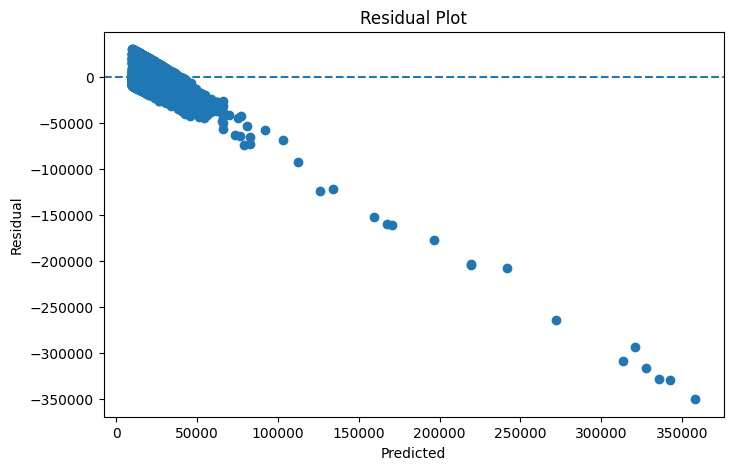

In [45]:
residual=y_test-y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred,residual)

plt.axhline(y=0,linestyle='--')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [46]:
import plotly.express as px

In [47]:
fig=px.scatter(
    df,
    x='annual_inc',
    y='loan_amnt',
    color='loan_status',
    title='Income vs Loan Amount'
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [48]:
fig=px.histogram(
    df,
    x='loan_amnt',
    title='Loan Distribution'
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [49]:
fig=px.histogram(
    df,
    x='loan_status',
    color='loan_status',
    title='Default Comparison'
)

fig.show()

In [50]:
fig=px.scatter(
    df,
    x='int_rate',
    y='loan_amnt',
    color='loan_status',
    title='Interest Rate vs Loan Amount'
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [51]:
fig=px.scatter(
    df,
    x='annual_inc',
    y='loan_amnt',
    color='purpose',
    facet_col='term',
    title='Income vs Loan Amount by Loan Term'
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.